<a href="https://colab.research.google.com/github/OrochinhodoTI/ia-ciberseguran-a_aula3/blob/main/Notebook_referencia_trocar_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Notebook de referência
## Trocar a base de dados no Notebook 3 (etapa "3. Carregamento dos dados")

Este notebook **substitui apenas o bloco de carregamento** do Notebook 3.
Escolha **uma** das seções abaixo, copie as células dela para o lugar do bloco
*"3. Carregamento dos dados"*, e siga o Notebook 3 normalmente a partir de
*"Verificando problemas nos dados"*.

**O contrato de cada seção:** ao final, você tem um DataFrame `df` que:
1. tem os nomes de coluna sem espaços (`df.columns.str.strip()`);
2. tem uma coluna de rótulo chamada **`Label`**;
3. tem o rótulo benigno padronizado como **`BENIGN`**.

Cumprido isso, todo o resto do Notebook 3 (limpeza, amostra, EDA, Random Forest,
K-Means) funciona **sem alterações** — ele usa `df` e `'Label'` de forma genérica.

> Todas as bases aqui são da família CIC (CSVs de fluxo do CICFlowMeter + coluna `Label`).
> A única diferença real entre elas é o **valor do benigno** — resolvida por uma linha de normalização.

In [1]:
# Comum a todas as seções
import os, glob
import numpy as np
import pandas as pd

---
## Opção A — CIC-IDS2017 (completo)
É a base atual do Notebook 3. Incluída aqui por completude.

In [ ]:
!gdown '1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP' -O CIC_IDS_2017.zip
!unzip -q -o CIC_IDS_2017.zip

In [ ]:
df_list = [pd.read_csv(f'MachineLearningCVE/{f}') for f in os.listdir('MachineLearningCVE/')]
df = pd.concat(df_list, ignore_index=True); del df_list
df.columns = df.columns.str.strip()

# normaliza o rótulo benigno para 'BENIGN'
df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:12], '...')
df.head()

---
## Opção B — CIC-IDS2017 (apenas um dia — mais leve)
Usa só o arquivo de quarta-feira (muitos ataques de DoS). Bom para máquinas fracas.

In [2]:
!gdown '1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP' -O CIC_IDS_2017.zip
!unzip -q -o CIC_IDS_2017.zip

Downloading...
From (original): https://drive.google.com/uc?id=1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP
From (redirected): https://drive.google.com/uc?id=1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP&confirm=t&uuid=012a2d60-e360-4055-99b0-68180bc270b9
To: /content/CIC_IDS_2017.zip
100% 235M/235M [00:02<00:00, 88.3MB/s]


In [3]:
# escolhe o CSV de quarta sem depender da grafia exata do nome
arq = [f for f in glob.glob('MachineLearningCVE/*.csv') if 'Wednesday' in f][0]
print('Arquivo:', arq)

df = pd.read_csv(arq)
df.columns = df.columns.str.strip()

df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:12], '...')
df.head()

Arquivo: MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Dimensões: (692703, 79)
Rótulos: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed'] ...


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


---
## Opção C — CSE-CIC-IDS2018 (apenas um dia — recomendado)
Continuação do 2017, mesmo esquema de ~80 features + `Label`. Baixamos **um** arquivo
limpo (28-02, ~200 MB) direto do AWS S3 público. Aqui o benigno vem como **`Benign`** —
a normalização cuida disso.

In [ ]:
!pip install -q awscli
!aws s3 cp --no-sign-request --region ca-central-1 "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv" wed2018.csv

In [ ]:
df = pd.read_csv('wed2018.csv', low_memory=False)
df.columns = df.columns.str.strip()

# 2018 usa 'Benign' (B maiúsculo) -> padroniza para 'BENIGN'
df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:12], '...')
df.head()

---
## Opção D — CSE-CIC-IDS2018 (vários dias)
Baixa a pasta de CSVs de fluxo e concatena. **Atenção:** é pesado (vários GB) e um dos
arquivos (Thursday-01-03-2018) tem colunas extras e cabeçalhos repetitivos — se der problema,
prefira a Opção C ou remova esse arquivo. Concatenamos só pelas colunas em comum.

In [ ]:
!pip install -q awscli
!aws s3 sync --no-sign-request --region ca-central-1 "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/" cse2018/

In [ ]:
arqs = sorted(glob.glob('cse2018/*.csv'))
# ignora o arquivo problemático de colunas extras (opcional)
arqs = [a for a in arqs if 'Thursday-01-03-2018' not in a]
print('Arquivos:', [os.path.basename(a) for a in arqs])

partes = [pd.read_csv(a, low_memory=False) for a in arqs]
partes = [p.rename(columns=lambda c: c.strip()) for p in partes]
cols_comuns = set.intersection(*[set(p.columns) for p in partes])
df = pd.concat([p[list(cols_comuns)] for p in partes], ignore_index=True)

df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:15], '...')
df.head()

---
## Opção E — Qualquer CSV da família CIC já no seu Google Drive
Para bases que você baixou manualmente (BCCC-CIC-IDS2017, CIC-DoS, um dia específico…).
Aponte a pasta e, se a coluna de rótulo tiver outro nome, ajuste `COL_ROTULO`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
PASTA      = '/content/drive/MyDrive/datasets/minha_base'   # <- ajuste
COL_ROTULO = 'Label'                                        # <- ajuste se necessário

arqs = glob.glob(f'{PASTA}/*.csv')
assert arqs, f'Nenhum CSV encontrado em {PASTA}'
df = pd.concat([pd.read_csv(a, low_memory=False) for a in arqs], ignore_index=True)
df.columns = df.columns.str.strip()

if COL_ROTULO != 'Label':
    df = df.rename(columns={COL_ROTULO: 'Label'})

# padroniza variações comuns de 'benigno' para 'BENIGN'
df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper().isin(['BENIGN', 'BENIGNO', 'NORMAL']), 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:15], '...')
df.head()

---
## Depois de carregar (qualquer opção)
Confira a coluna alvo e siga o Notebook 3 a partir de *"Verificando problemas nos dados"*.

In [4]:
print('Coluna alvo: Label ->', df['Label'].unique()[:8], '...')
df.info()

Coluna alvo: Label -> ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed'] ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             692703 non-null  int64  
 1   Flow Duration                692703 non-null  int64  
 2   Total Fwd Packets            692703 non-null  int64  
 3   Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets  692703 non-null  int64  
 5   Total Length of Bwd Packets  692703 non-null  int64  
 6   Fwd Packet Length Max        692703 non-null  int64  
 7   Fwd Packet Length Min        692703 non-null  int64  
 8   Fwd Packet Length Mean       692703 non-null  float64
 9   Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max        692703 non-null  int64  
 11  Bwd 

# limbeza de dados


In [5]:
import numpy as np


df.replace([np.inf, -np.inf], np.nan, inplace=True)


print("Top 5 colunas com valores nulos:")
print(df.isna().sum().sort_values(ascending=False).head(5))


df.dropna(inplace=True)

print("\nDimensões da base APÓS a limpeza:", df.shape)

Top 5 colunas com valores nulos:
Flow Bytes/s                   1297
Flow Packets/s                 1297
Flow Duration                     0
Total Backward Packets            0
Total Length of Fwd Packets       0
dtype: int64

Dimensões da base APÓS a limpeza: (691406, 79)


parte de Exploração Inicial (Distribuição das Classes)

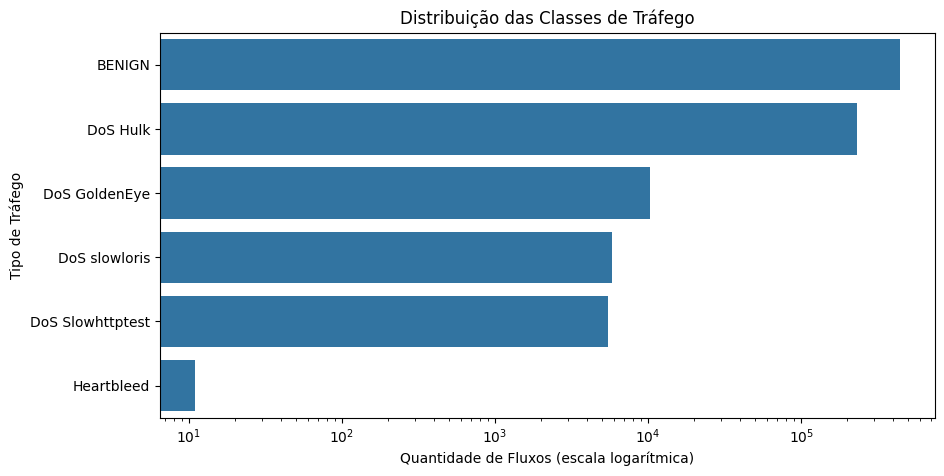


Contagem exata por classe:
Label
BENIGN              439683
DoS Hulk            230124
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))


sns.countplot(data=df, y='Label', order=df['Label'].value_counts().index)

plt.title('Distribuição das Classes de Tráfego')
plt.xlabel('Quantidade de Fluxos (escala logarítmica)')
plt.ylabel('Tipo de Tráfego')
plt.xscale('log')

plt.show()


print("\nContagem exata por classe:")
print(df['Label'].value_counts())